In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# Load datasets - replace with your own file paths or place all CSVs in a folder
data_files = [
    "uber-raw-data-apr14.csv",
    "uber-raw-data-may14.csv",
    "uber-raw-data-jun14.csv",
    "uber-raw-data-jul14.csv",
    "uber-raw-data-aug14.csv",
    "uber-raw-data-sep14.csv"
]

# Read and concatenate all monthly data
dfs = []
for file in data_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except FileNotFoundError:
        print(f"File not found: {file}")

# Combine all data
df = pd.concat(dfs, ignore_index=True)
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (4534327, 4)


In [2]:
# Convert Date/Time column to datetime object
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Day'] = df['Date/Time'].dt.day
df['Weekday'] = df['Date/Time'].dt.dayofweek
df['Hour'] = df['Date/Time'].dt.hour

# Basic info and head
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date/Time  datetime64[ns]
 1   Lat        float64       
 2   Lon        float64       
 3   Base       object        
 4   Day        int32         
 5   Weekday    int32         
 6   Hour       int32         
dtypes: datetime64[ns](1), float64(2), int32(3), object(1)
memory usage: 190.3+ MB
None


,Date/Time,Lat,Lon,Base,Day,Weekday,Hour
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,1,1,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,1,1,0
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,1,1,0
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,1,1,0
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,1,1,0


C:\Users\HP\AppData\Local\Temp\ipykernel_5560\2974186989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hour', palette='coolwarm')


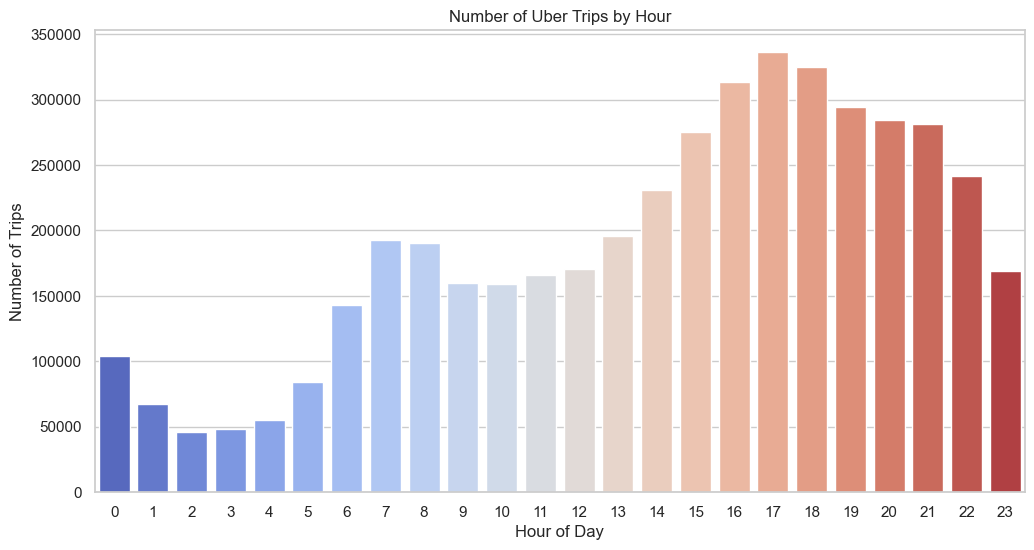

In [3]:
# Plot number of trips per hour
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Hour', palette='coolwarm')
plt.title("Number of Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5560\3769643276.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weekday', palette='viridis')


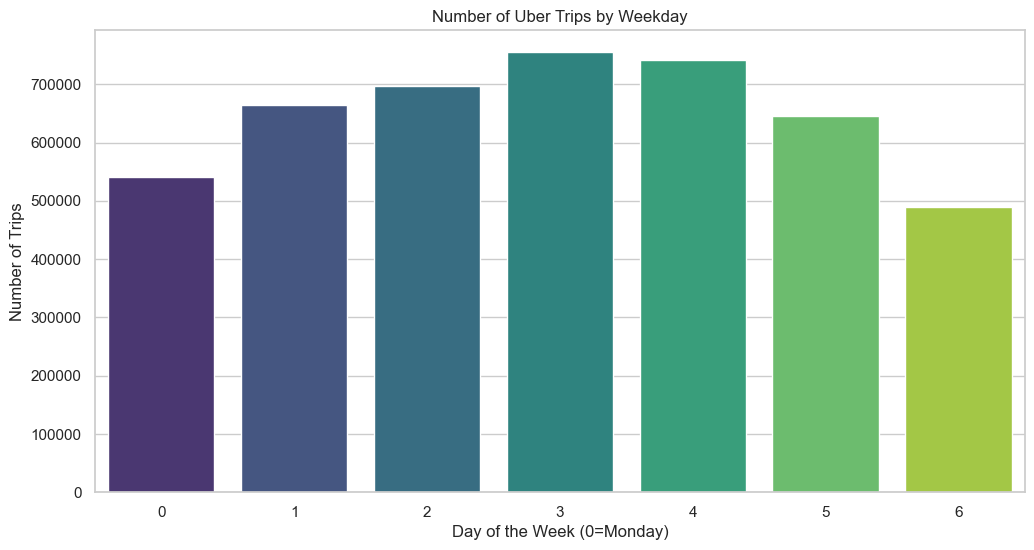

In [4]:
# Plot trips by weekday
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Weekday', palette='viridis')
plt.title("Number of Uber Trips by Weekday")
plt.xlabel("Day of the Week (0=Monday)")
plt.ylabel("Number of Trips")
plt.show()

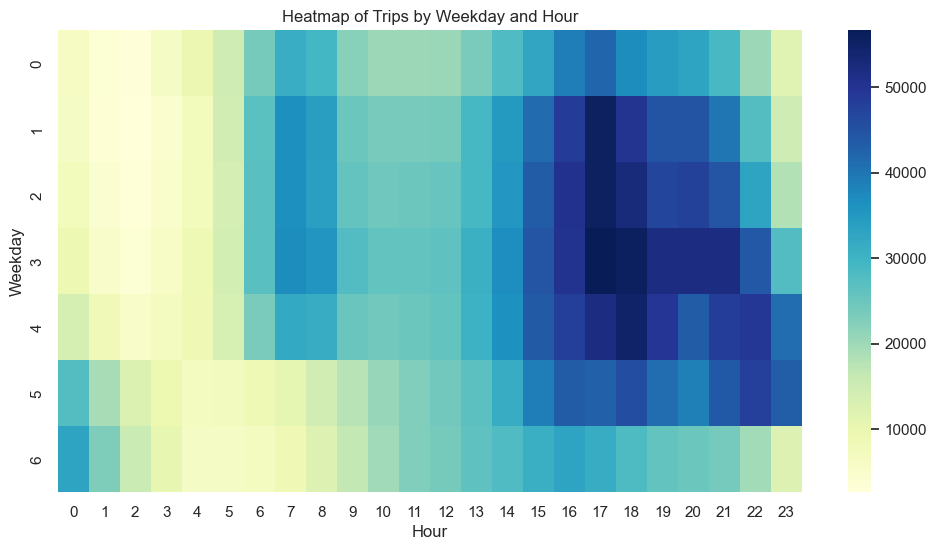

In [5]:
# Heatmap: Weekday vs Hour
heatmap_data = df.groupby(['Weekday', 'Hour']).size().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("Heatmap of Trips by Weekday and Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()